<a href="https://colab.research.google.com/github/aidandreyes/WNBA-DPOY-Predictor/blob/main/wnba_defense_09_19_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analyzing the Defensive DNA of the WNBA** by Aidan Reyes
## - **What statistics make a player the Defensive Player of the Year?**



---



The data of this project comes from the official [WNBA website](https://stats.wnba.com/) and [Basketball Reference](https://www.basketball-reference.com/).

NOTE: The statistics are based on PER 100 POSSESSIONS to adjust for game pace and put players on a more equal scale in terms of playing time for comparison.

PER 100 POSSESSIONS = (Stat Total / Total # of Possessions) * 100

Sources:

- [2025 player stats](https://stats.wnba.com/players/defense/?sort=PLAYER_NAME&dir=-1&Season=2025&SeasonType=Regular%20Season&PerMode=Per100Possessions) / [2025 team stats](https://www.basketball-reference.com/wnba/years/2025.html)
- [2024 player stats](https://stats.wnba.com/players/defense/?sort=PLAYER_NAME&dir=-1&Season=2024&SeasonType=Regular%20Season&PerMode=Per100Possessions) / [2024 team stats](https://www.basketball-reference.com/wnba/years/2024.html)

- [2023 player stats](https://stats.wnba.com/players/defense/?sort=PLAYER_NAME&dir=-1&Season=2023&SeasonType=Regular%20Season&PerMode=Per100Possessions) / [2023 team stats](https://www.basketball-reference.com/wnba/years/2023.html)

- [2022 player stats](https://stats.wnba.com/players/defense/?sort=PLAYER_NAME&dir=-1&Season=2022&SeasonType=Regular%20Season&PerMode=Per100Possessions) / [2022 team stats](https://www.basketball-reference.com/wnba/years/2022.html)

- [2021 player stats](https://stats.wnba.com/players/defense/?sort=PLAYER_NAME&dir=-1&Season=2021&SeasonType=Regular%20Season&PerMode=Per100Possessions) / [2021 team stats](https://www.basketball-reference.com/wnba/years/2021.html)

The .csv files can be downloaded from this [folder](https://drive.google.com/drive/folders/1YLAaPzbrMxmwE71M46i7hWFABBjPImdu?usp=drive_link).

NOTE FOR ME:

Create team defense stats .csv / dataframe for each season and merge by team, season
- https://stats.wnba.com/teams/defense/?sort=W&dir=-1&Season=2025&SeasonType=Regular%20Season&PerMode=Per100Possessions

Take defensive four factors (eFG%, TOV%, DRB%, FT/FGA), opponent shooting stats/per 100 possessions
- https://www.basketball-reference.com/wnba/years/2025.html



---

## **Loading & Cleaning Data**

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
defense_2021 = pd.read_csv('/content/wnba_defense_2021.csv')
defense_2022 = pd.read_csv('/content/wnba_defense_2022.csv')
defense_2023 = pd.read_csv('/content/wnba_defense_2023.csv')
defense_2024 = pd.read_csv('/content/wnba_defense_2024.csv')
defense_2025 = pd.read_csv('/content/wnba_defense_2025.csv')
team_defense = pd.read_csv('/content/team_defense.csv')
opponent_stats = pd.read_csv('/content/team_opponent_stats.csv')

In [ ]:
# Combine into one dataframe
player_df = pd.concat([defense_2021, defense_2022, defense_2023, defense_2024, defense_2025])

# Delete team wins and team losses from player_df (team win pct will show later)
player_df = player_df.drop(columns=['wins', 'losses'])

# Delete team variables due to redundancy (other team vars will show later)
player_df = player_df.drop(columns=['pct_team_dreb', 'opp_pts_off_tov','opp_pts_2nd_chance','opp_pts_fb','opp_pts_paint'])

player_df.info()

In [ ]:
player_df.head()

In [ ]:
# Add column into dataframe that indicates player won DPOY award
player_df['dpoy_winner'] = 0

# Add column for DPOY winners
winners = {
    2021: ["Sylvia Fowles"],
    2022: ["A'ja Wilson"],
    2023: ["A'ja Wilson"],
    2024: ["Napheesa Collier"],
    2025: ["Alanna Smith", "A'ja Wilson"]
}

for winner in winners:
    player_names = winners[winner]
    for player_name in player_names:
        player_df.loc[(player_df['player'] == player_name) & (player_df['season'] == winner), 'dpoy_winner'] = 1

In [ ]:
# Merging team stats / opponent stats
team_df = pd.merge(team_defense, opponent_stats, on=['team', 'season'], how='inner')

# Delete team_wins and team_losses (redundant, win percentage already there)
team_df = team_df.drop(columns=['team_wins', 'team_losses'])

In [ ]:
team_df.info()

I had a data error where one season for the Phoenix Mercury was abbreviated as PHX while the other four were abbreviated as PHO. For data cleaning purposes, I adjusted them to match so that merging on team as one of the keys would work out.

In [ ]:
# Standardize 'PHX' to 'PHO' in player_df
player_df['team'] = player_df['team'].replace({'PHX': 'PHO'})

To use team as one of the key variables for merging the two datasets, I had to match the teams to their abbreviations.

In [ ]:
# Convert team names on team_df to abbreviation to match player_df
abbreviation_mapping = {
    'Atlanta Dream': 'ATL',
    'Chicago Sky': 'CHI',
    'Connecticut Sun': 'CON',
    'Dallas Wings': 'DAL',
    'Golden State Valkyries': 'GSV',
    'Indiana Fever': 'IND',
    'Las Vegas Aces': 'LVA',
    'Los Angeles Sparks': 'LAS',
    'Minnesota Lynx': 'MIN',
    'New York Liberty': 'NYL',
    'Phoenix Mercury': 'PHO',
    'Seattle Storm': 'SEA',
    'Washington Mystics': 'WAS'
}

# Apply the mapping to the 'team' column in team_df
team_df['team'] = team_df['team'].replace(abbreviation_mapping)

In [ ]:
# Merge player and team into one big data frame
defense_df = pd.merge(player_df, team_df, on=['season', 'team'], how='inner')

defense_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player            816 non-null    object 
 1   team              816 non-null    object 
 2   season            816 non-null    int64  
 3   age               816 non-null    int64  
 4   gp                816 non-null    int64  
 5   minutes           816 non-null    float64
 6   def_rtg           816 non-null    float64
 7   dreb              816 non-null    float64
 8   dreb_pct          816 non-null    float64
 9   stl               816 non-null    float64
 10  stl_pct           816 non-null    float64
 11  blk               816 non-null    float64
 12  blk_pct           816 non-null    float64
 13  def_ws            816 non-null    float64
 14  dpoy_winner       816 non-null    int64  
 15  team_win_pct      816 non-null    float64
 16  team_def_rtg      816 non-null    float64
 1

Here is the clean dataset **defense_df**. This includes the individual player defensive stats, now along with their team defensive stats from that season. This will help see if their individual defensive impact ultimately mattered to their team's defensive success. There are 816 player entries along with 27 columns.

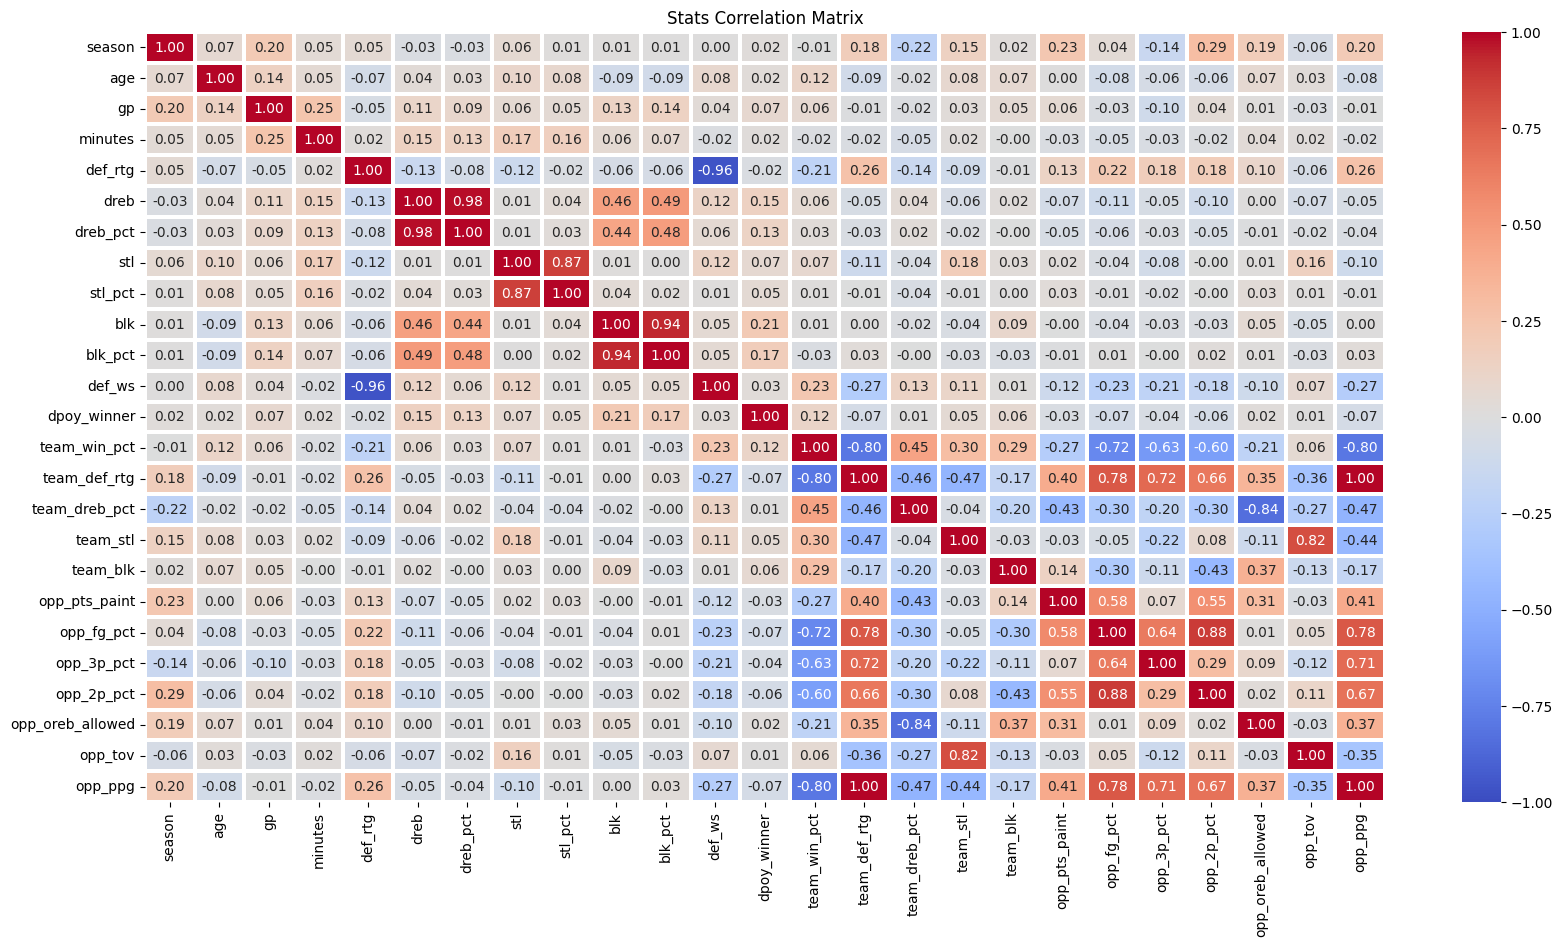

In [ ]:
matrix = defense_df.corr(numeric_only=True)
plt.figure(figsize=(20, 10))
sns.heatmap(
    matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt=".2f",
    linewidths=1.5
)

plt.title('Stats Correlation Matrix')
plt.show()



---
## **Exploratory Data Analysis & Data Visualization**

## Defensive Rating of DPOY Winners

In [ ]:

dpoy_winners_df = defense_df[defense_df['dpoy_winner'] == 1]

plt.figure(figsize=(12, 7))
sns.scatterplot(x='player', y='def_rtg', data=dpoy_winners_df, hue='season', s=150, palette='viridis', legend='full')
plt.title('Defensive Rating for DPOY Winners by Season')
plt.xlabel('Player')
plt.ylabel('Defensive Rating')
plt.xticks(rotation=45, ha='right')

# Calculate and add the mean def_rtg line for the entire league
mean_league_def_rtg = defense_df['def_rtg'].mean()
plt.axhline(y=mean_league_def_rtg, color='red', linestyle='--', label=f'League Average Defensive Rating: {mean_league_def_rtg:.2f}')

# Calculate and add the mean def_rtg line for DPOY winners
mean_dpoy_def_rtg = dpoy_winners_df['def_rtg'].mean()
plt.axhline(y=mean_dpoy_def_rtg, color='blue', linestyle=':', label=f'DPOY Winner Average Defensive Rating: {mean_dpoy_def_rtg:.2f}')

plt.legend(title='Season & Stats')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()